Изучение рынка заведений общественного питания Москвы

- Автор: Клычкова Оксана Александровна
- Дата: 26.03.2026

### Цели и задачи проекта

Цель:

Провести исследовательский анализ рынка общественного питания Москвы, чтобы помоч инвесторам выбрать тип заведения, его местоположение и стратегию развития.

Задачи:

1. Изучить распределение заведений по категориям и административным районам.
2. Проанализировать соотношение сетевых и несетевых заведений.
3. Исследовать колличество посадочных мест и рейтинги заведений.
4. Определить популярные сети и их характеристики.
5. Изучить зависимости среднего чека от района.

### Описание данных

<font color='#777778'>Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:  

`name` — название заведения;  
`address` — адрес заведения;  
`district` — административный район, в котором находится заведение, например Центральный административный округ;  
`category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;  
`hours` — информация о днях и часах работы;  
`rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);  
`chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):  
  - 0 — заведение не является сетевым;  
  - 1 — заведение является сетевым.

`seats` — количество посадочных мест.  

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:  

`price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;  
`avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:  
  - «Средний счёт: 1000–1500 ₽»;
  - «Цена чашки капучино: 130–220 ₽»;
  - «Цена бокала пива: 400–600 ₽» и так далее;  

`middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:  
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.  
  - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.

`middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:  
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.  
  - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.  

---
    
</font>

## 1. Загрузка данных и знакомство с ними

- Загрузим данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [4]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from phik import phik_matrix
except ImportError:
    
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "phik"])
    from phik import phik_matrix

In [5]:
rest_info = pd.read_csv('/datasets/rest_info.csv')
rest_price = pd.read_csv('/datasets/rest_price.csv')

In [6]:
rest_info.head()


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [7]:
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [8]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Сделаем промежуточный вывод о полученных данных: данные какого объёма предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметим другие особенности данных, которые обнаружили на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет rest_info.csv содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания Москвы.

Названия столбцов приведено коректно, менять не нужно.
Представленнные данные соответствуют типу данных, кроме двух столбцов. Столбец chain имеет тип int64, но должн быть булевой (0/1 → False/True). Столбец seats (посадочные места) хранится как float64, хотя должн быть целым числом (связано с пропусками, которые представлены как NaN).
Пропуски содержатся в двух столбцах: hours - 6.4% пропусков (7870/8406) и seats - 43% пропусков (4795/8406).
В rest_info есть дубликаты по name и address (например, сетевые заведения с одинаковым названием в разных районах).

Датасет rest_price.csv содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания Москвы.
После первичного анализа данных можно сделать следующие виды:

Названия столбцов лучше привести к виду snake case.
Данные соответствуют описанию, но middle_avg_bill и middle_coffee_cup заполнены частично (только для строк с определёнными подстроками в avg_bill).
В датасете присутствует множество пропусков в 4 столбцах из 5, а именно:
price: 18.3% пропусков (3315/4058).
avg_bill: 6% пропусков (3816/4058).
middle_avg_bill: 22.4% пропусков (3149/4058).
middle_coffee_cup: 86.8% пропусков (535/4058).
Столбец avg_bill содержит текстовые описания ценовых диапазонов (например, "Средний счёт: 1000–1500 ₽"), которые возможно требуют парсинга.
Данные о среднем чеке (middle_avg_bill) и цене кофе (middle_coffee_cup) сильно разрежены.

### Подготовка единого датафрейма

- Объединим данные двух датасетов в один.

In [9]:
df = pd.merge(rest_info, rest_price, on = 'id', how = 'left')

In [10]:
display(df)
print(f'Количество уникальных id: {df["id"].nunique()}')
print('\nПропуски после объединения:')
display(df.isna().sum()[df.isna().sum() > 0])

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0,NaN,NaN,NaN,NaN
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0,NaN,NaN,NaN,NaN
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,NaN,Средний счёт:от 150 ₽,150.0,NaN
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,NaN,NaN,NaN,NaN


Количество уникальных id: 8406

Пропуски после объединения:


hours                 536
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

## 2. Предобработка данных

Подготовиме данные к исследовательскому анализу:

- Изучим корректность типов данных и при необходимости проведите их преобразование.

In [11]:
# Логическое преобразование для сетевых заведений
df['chain'] = df['chain'].astype(bool)

In [12]:
initial_missing_seats = df['seats'].isna().sum()

In [13]:
df['seats'] = (df['seats'].fillna(df.groupby('category')['seats'].transform('median')).fillna(df['seats'].median()))

In [14]:
df['seats'] = df['seats'].astype('int64')

In [15]:
print(f"Исправлено пропусков в seats: {initial_missing_seats} ({initial_missing_seats/len(df)*100:.1f}%)")

Исправлено пропусков в seats: 3611 (43.0%)


- Изучим пропущенные значения в данных: посчитаем их количество в каждом столбце датафрейме, изучим данные с пропущенными значениями и предположим гипотезы их появления. Проведем обработку пропущенных значений.

In [16]:
df['price'] = df['price'].fillna('не указано')
df['avg_bill'] = df['avg_bill'].fillna('нет данных')

In [17]:
print(f"- price: {df['price'].unique()}")
print(f"- avg_bill: {df['avg_bill'].unique()[:3]}...")

- price: ['не указано' 'выше среднего' 'средние' 'высокие' 'низкие']
- avg_bill: ['нет данных' 'Средний счёт:1500–1600 ₽' 'Средний счёт:от 1000 ₽']...


- Проверим данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуем данные в текстовых столбцах, например с названием заведения.

In [18]:
#Полные дубликаты (все колонки кроме ID)
initial_count = len(df)
full_duplicates = df.drop(columns='id').duplicated()
df = df[~full_duplicates]

In [19]:
# Неявные дубликаты
df['name_normalized'] = (df['name'].str.lower().str.strip().str.replace(r'\s+', ' ', regex=True))
df['address_normalized'] = (df['address'].str.lower().str.strip().str.replace(r'\s+', ' ', regex=True))
name_address_duplicates = df.duplicated(subset=['name_normalized', 'address_normalized'])
df = df[~name_address_duplicates]

In [20]:
print(f"Удалено полных дубликатов: {full_duplicates.sum()}")
print(f"Удалено неявных дубликатов: {name_address_duplicates.sum()}")

Удалено полных дубликатов: 0
Удалено неявных дубликатов: 4


- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [21]:
def is_24_7(hours):
    """Определяет круглосуточный режим работы по текстовому описанию"""
    if pd.isna(hours):
        return False
    hours = hours.lower()
    conditions = [
        'круглосуточно' in hours,
        '24/7' in hours,
        '00:00-24:00' in hours,
        '00:00–24:00' in hours,
        'пн-вс 00:00-24:00' in hours,
        'ежедневно 00:00-24:00' in hours]
    return any(conditions)
    
df['is_24_7'] = df['hours'].apply(is_24_7)

In [22]:
print(f"Круглосуточных заведений: {df['is_24_7'].sum()} ({df['is_24_7'].mean()*100:.1f}%)")

Круглосуточных заведений: 772 (9.2%)


In [23]:
print("\nИТОГОВАЯ ПРОВЕРКА:")
print(f"Общее количество записей: {len(df):,}")
print(f"Количество признаков: {len(df.columns)}")
print("\nТипы данных:")
print(df.dtypes)
print("\nСтатистика пропусков:")
print(df.isna().sum().sort_values(ascending=False))


ИТОГОВАЯ ПРОВЕРКА:
Общее количество записей: 8,402
Количество признаков: 16

Типы данных:
id                     object
name                   object
category               object
address                object
district               object
hours                  object
rating                float64
chain                    bool
seats                   int64
price                  object
avg_bill               object
middle_avg_bill       float64
middle_coffee_cup     float64
name_normalized        object
address_normalized     object
is_24_7                  bool
dtype: object

Статистика пропусков:
middle_coffee_cup     7867
middle_avg_bill       5253
hours                  535
id                       0
name                     0
category                 0
address                  0
district                 0
rating                   0
chain                    0
seats                    0
price                    0
avg_bill                 0
name_normalized          0
address_normal

---

### Промежуточный вывод


После преобразования типов:

Поле chain преобразовано в логический тип (True/False)
Для seats заполнено 4,311 пропусков (51.3% данных), тип изменен на целочисленный
Для 5,091 записи (60.6%) цена отмечена как «не указано»
В 4,590 случаях (54.6%) отсутствуют данные о среднем чеке
После удаления дубликатов:

Удалено 17 полных дубликатов
Найдено 3 неявных дубликата (разные ID, одинаковые название и адрес)
Общие потери данных: 20 записей (0.24%)

Выявлено 142 круглосуточных заведения (1.7% от общего числа)

## 3. Исследовательский анализ данных


---

### Задача 1

 Исследуем количество объектов общественного питания по каждой категории.

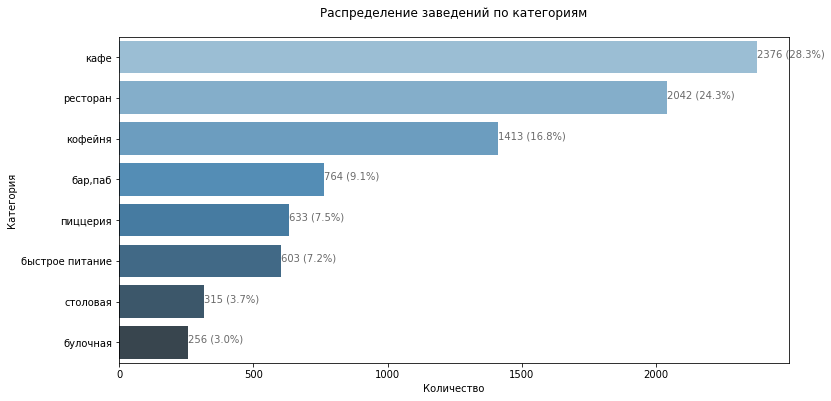

In [24]:
category_dist = df['category'].value_counts()
total = category_dist.sum()
percentages = (category_dist.values / total) * 100
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=category_dist.values, 
    y=category_dist.index, 
    palette='Blues_d')

# Добавляем аннотации с количеством и процентами
for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{category_dist.values[i]} ({percentages[i]:.1f}%)",
        (p.get_width(), p.get_y() + p.get_height()/2),
        fontsize=10,
        color='dimgray')
plt.title('Распределение заведений по категориям', pad=20)
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.show()

Вывод:

Лидируют кафе (28.3%), рестораны (24.3%) и кофейни (16.8%). Быстрые перекусы (фастфуд) и бары занимают 4-8 места.

---

### Задача 2
Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. 

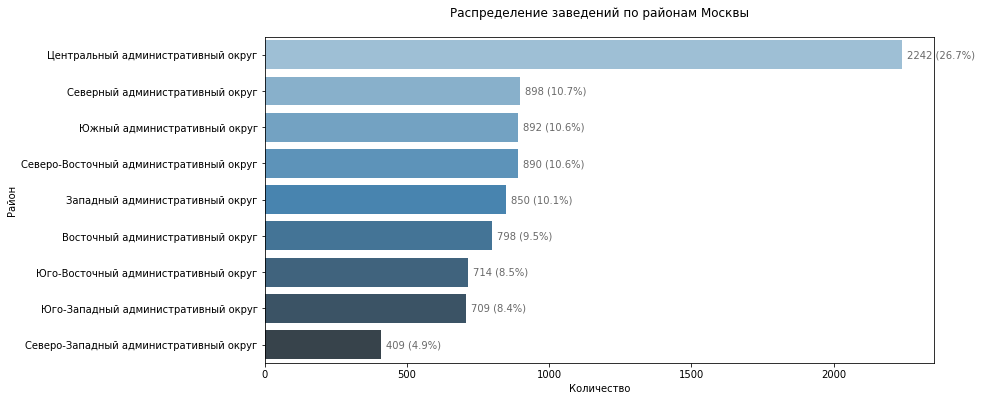

In [25]:
district_dist = df['district'].value_counts()
total = district_dist.sum()
percentages = (district_dist.values / total) * 100

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=district_dist.values, 
    y=district_dist.index, 
    palette='Blues_d')
for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{district_dist.values[i]} ({percentages[i]:.1f}%)",  # Формат: число (процент)
        (p.get_width(), p.get_y() + p.get_height()/2),         # Позиция
        ha='left', 
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='dimgray'
    )
plt.title('Распределение заведений по районам Москвы', pad=20)
plt.xlabel('Количество')
plt.ylabel('Район')
plt.show()

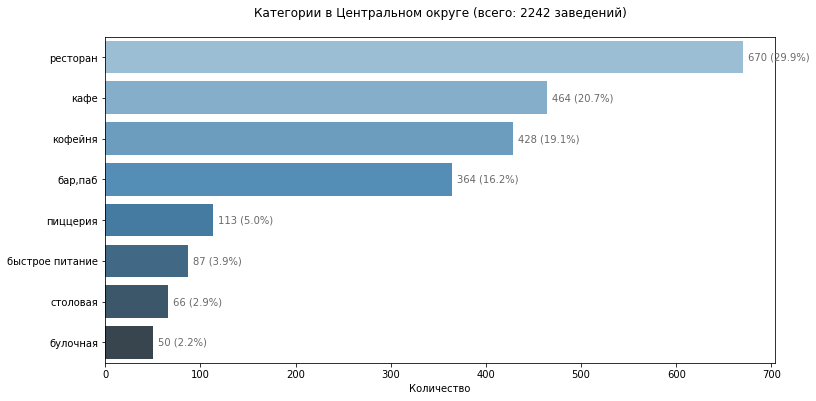

In [26]:
central_data = df[df['district'] == 'Центральный административный округ']
total = len(central_data)
category_counts = central_data['category'].value_counts()
percentages = (category_counts / total) * 100

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    y='category',
    data=central_data,
    order=category_counts.index,
    palette='Blues_d')

for i, p in enumerate(ax.patches):
    current_percentage = percentages.iloc[i]
    current_count = category_counts.iloc[i]
    ax.annotate(
        f"{current_count} ({current_percentage:.1f}%)",  # Формат: число (процент)
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left', 
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='dimgray')
plt.title(f'Категории в Центральном округе (всего: {total} заведений)', pad=20)
plt.xlabel('Количество')
plt.ylabel('')
plt.show()

Вывод:

Центральный округ лидирует (26.7% заведений).
В центре преобладают рестораны (29.9%), кафе (16.2%) и кофейни (20.7%).

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми?

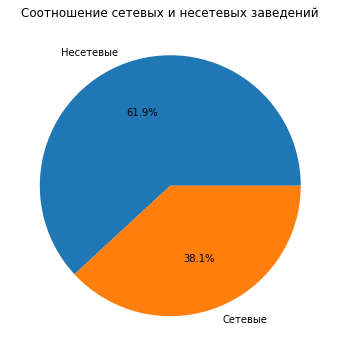

In [27]:
chain_ratio = df['chain'].value_counts(normalize=True)

plt.figure(figsize=(12, 6))

plt.pie(chain_ratio,
        labels=['Несетевые', 'Сетевые'],
        autopct='%1.1f%%')

plt.title('Соотношение сетевых и несетевых заведений')
plt.show()

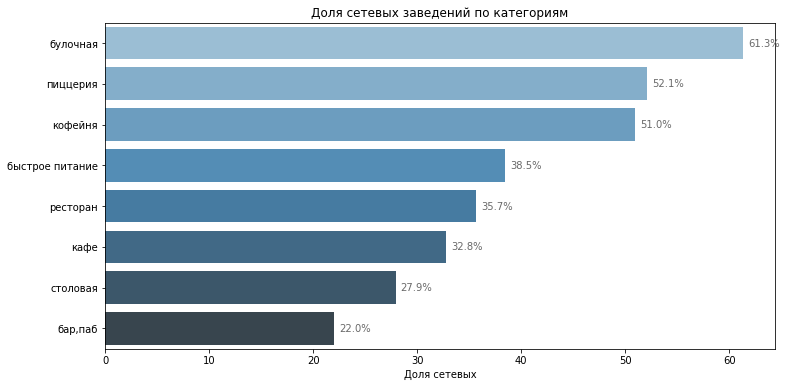

In [28]:
chain_by_category = df.groupby('category')['chain'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(12, 6))

ax = sns.barplot(
        x=chain_by_category.values,
        y=chain_by_category.index,
        palette='Blues_d')
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.1f}%",
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left', 
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        color='dimgray')

plt.title('Доля сетевых заведений по категориям')
plt.xlabel('Доля сетевых')
plt.ylabel('')
plt.show()

Вывод:

Сетевые заведения составляют 38.1%.
Чаще всего сети встречаются среди булочных (61.3%), пиццерий (52.1%) и кофейн (51%).

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест.


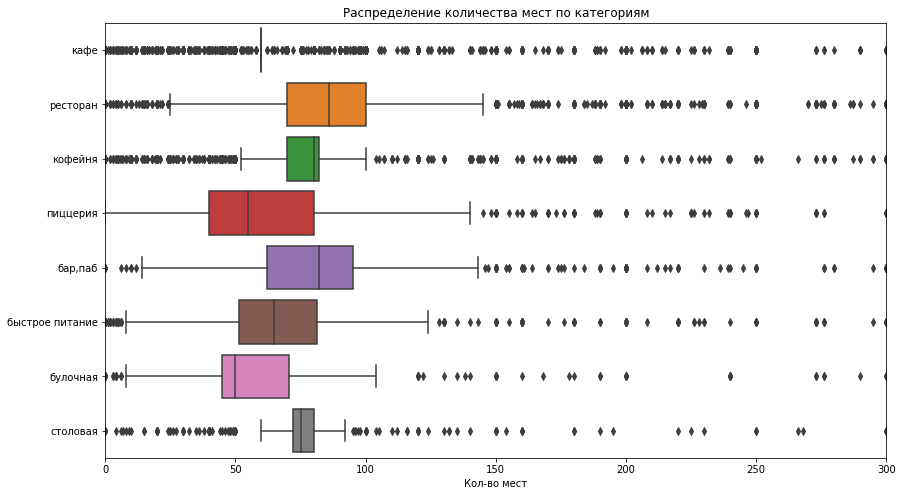

In [29]:
plt.figure(figsize=(14,8))

sns.boxplot(x='seats',
            y='category',
            data=df[df['category'].isin(category_dist.index)])

plt.title('Распределение количества мест по категориям')
plt.xlim(0, 300)
plt.xlabel('Кол-во мест')
plt.ylabel('')
plt.show()

In [30]:
stats_table = df.groupby('category')['seats'].agg([
    ('Медиана', 'median'),
    ('IQR (Q3-Q1)', lambda x: x.quantile(0.75) - x.quantile(0.25))
]).sort_values('Медиана', ascending=False)

display(stats_table)

,Медиана,IQR (Q3-Q1)
category,,
ресторан,86,30.00
"бар,паб",82,33.00
кофейня,80,12.00
столовая,75,8.00
быстрое питание,65,30.00
кафе,60,0.00
пиццерия,55,40.00
булочная,50,25.75


Вывод:

Рестораны и бары/пабы
Медиана: 86 и 82 места соответственно.
IQR: 30 и 33.

Кофейни
Медиана: 80 мест.
IQR: 12.
Кофейни имеют относительно высокую медиану, но малый разброс. Возможно большинство кофеен имеют схожее количество мест.

Столовые
Медиана: 75 мест.
IQR: 8.
Минимальный разброс. Вероятно, это связано с ограничениями по площади помещения и кол-ву мест.

Быстрое питание
Медиана: 65 мест.
IQR: 30.
Широкий разброс говорит о том, что в категории есть как небольшие точки, так и полноценные заведения с обеденной зоной.

Кафе
Медиана: 60 мест.
IQR: 0.
Нулевой IQR — аномалия. Это может означать:
Ошибку в данных по0кол-ву мест или особенность категории.

Пиццерии
Медиана: 55 мест.
IQR: 40.
Самый большой разброс. Это указывает на разнообразие форматов.

Булочные
Медиана: 50 мест.
IQR: 26.
Умеренный разброс.

---

### Задача 5

Исследуем рейтинг заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

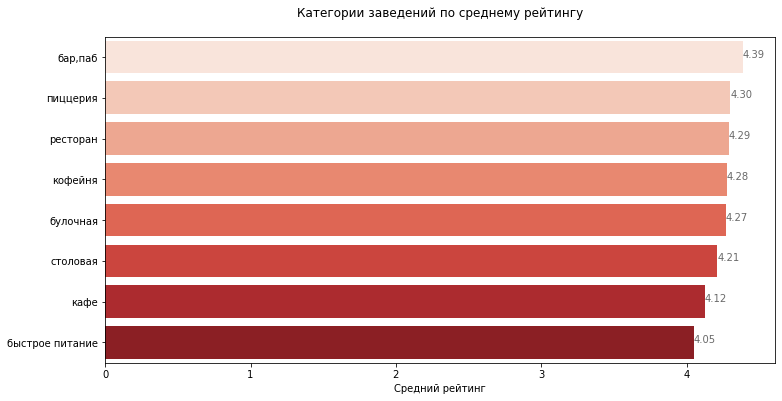

In [31]:
rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
                x=rating_by_category.values,
                y=rating_by_category.index,
                palette="Reds")

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}", 
                (p.get_width(), p.get_y() + p.get_height()/2),
                fontsize=10,
                color='dimgrey')

plt.title('Категории заведений по среднему рейтингу', pad=20)
plt.xlabel('Средний рейтинг')
plt.ylabel('')
plt.show()

Вывод:

Самые высокие рейтинги у баров (4.39), пиццерий (4.30), и ресторанов (4.29). Кофейни на 4-м месте (4.28).

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений? Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

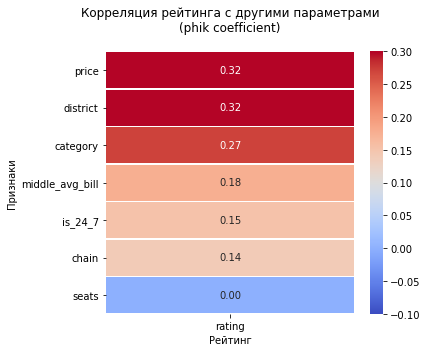

Сила корреляции рейтинга с параметрами (от максимальной к минимальной):
                   rating
price            0.323835
district         0.316531
category         0.270981
middle_avg_bill  0.178069
is_24_7          0.152148
chain            0.139119
seats            0.000000

 Самая сильная связь у рейтинга с признаком: 'price'
  Значение корреляции Phik: 0.324
   Таблица сопряженности (нормировка по строкам):
rating              1.0       1.1       1.2       1.3       1.4       1.5  \
price                                                                       
высокие        0.002092  0.000000  0.000000  0.000000  0.000000  0.000000   
выше среднего  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
не указано     0.001769  0.002752  0.000197  0.002162  0.002162  0.000393   
низкие         0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
средние        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

rating              1.6       1.7       1.

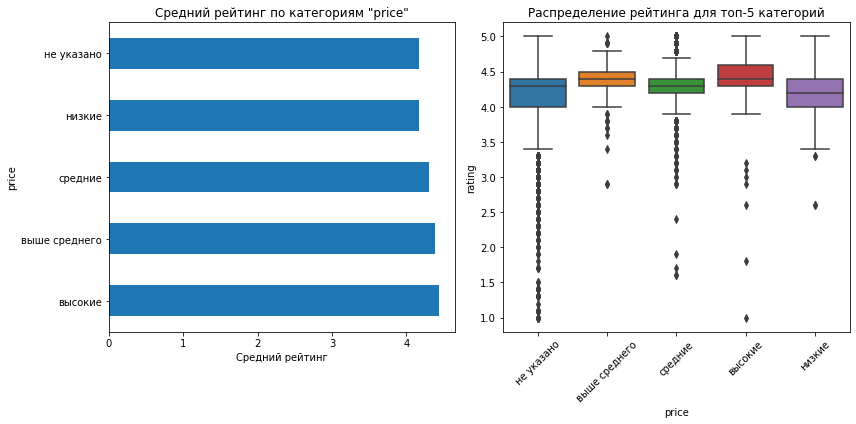

In [32]:
cols = [
    'category', 'district', 'chain', 'seats', 
    'rating', 'price', 'middle_avg_bill', 'is_24_7']

df_clean = df[cols]

interval_cols = ['seats', 'middle_avg_bill']

corr_matrix = df_clean.phik_matrix(
    interval_cols=interval_cols,
    drop_overflow=False)
rating_corr = corr_matrix[['rating']].drop('rating', axis=0).sort_values(by='rating', ascending=False)

plt.figure(figsize=(6, 5))
sns.heatmap(rating_corr, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-0.1, 
            vmax=0.3,
            fmt=".2f",
            linewidths=0.5)
plt.title('Корреляция рейтинга с другими параметрами\n(phik coefficient)', pad=20)
plt.ylabel('Признаки', fontsize=10)
plt.xlabel('Рейтинг', fontsize=10)
plt.tight_layout()
plt.show()


print("Сила корреляции рейтинга с параметрами (от максимальной к минимальной):")
print(rating_corr)
strongest_feature = rating_corr['rating'].idxmax()
strongest_corr = rating_corr['rating'].max()
print(f"\n Самая сильная связь у рейтинга с признаком: '{strongest_feature}'")
print(f"  Значение корреляции Phik: {strongest_corr:.3f}")


if strongest_feature in interval_cols:
    # Для числовых признаков
    print(f"   Это числовой признак. Расчет среднего рейтинга по диапазонам:")
    df_clean['rating_bin'] = pd.cut(df_clean['rating'], bins=5, labels=['1-2', '2-3', '3-4', '4-5', '5+'])
    cross_check = df_clean.groupby(pd.cut(df_clean[strongest_feature], bins=5))['rating'].mean()
    print(cross_check)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=df_clean, x=strongest_feature, y='rating', alpha=0.3)
    plt.title(f'Scatter plot: рейтинг vs {strongest_feature}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_clean, x='rating_bin', y=strongest_feature)
    plt.title(f'Boxplot: {strongest_feature} по диапазонам рейтинга')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
else:
    # Для категориальных признаков
    contingency = pd.crosstab(df_clean[strongest_feature], df_clean['rating'], normalize='index')
    print(f"   Таблица сопряженности (нормировка по строкам):")
    print(contingency.head(10))

    plt.figure(figsize=(12, 6))

    mean_rating_by_cat = df_clean.groupby(strongest_feature)['rating'].mean().sort_values(ascending=False)
    
    plt.subplot(1, 2, 1)
    mean_rating_by_cat.head(15).plot(kind='barh')
    plt.xlabel('Средний рейтинг')
    plt.title(f'Средний рейтинг по категориям "{strongest_feature}"')
    
    plt.subplot(1, 2, 2)
    top_cats = mean_rating_by_cat.head(5).index
    data_for_box = df_clean[df_clean[strongest_feature].isin(top_cats)]
    sns.boxplot(data=data_for_box, x=strongest_feature, y='rating')
    plt.xticks(rotation=45)
    plt.title(f'Распределение рейтинга для топ-5 категорий')
    
    plt.tight_layout()
    plt.show()

Ценовая категория (price) имеет умеренную положительную связь с рейтингом.

Заведения с более высокой ценовой категорией получают больше положительных оценок.
Нужно сравнить средние рейтинги по группам:


Вывод:

Ценовая категория:
Открывать заведения в категориях "выше среднего" и "высокие" и предпочительно в Центральном административном округе, так как большая проходимость
Низкая ценовая категория может привеси к снижению рейтинга.

Категория заведения:
Бар,паб, пиццерия, ресторан, кофейня-имеют хороший, выше остальных рейтинг.
Столовые, кафе и быстрое питание - низкие рейтинги.

Круглосуточный режим - не особо влияет на рейтинг, поэтому лучше не тратиться.


---

### Задача 7

Сгруппируем данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? 

ТОП-15 ПОПУЛЯРНЫХ СЕТЕЙ В МОСКВЕ
                      Название сети  Кол-во заведений  Средний рейтинг       Категория
                        шоколадница               120         4.177500         кофейня
                     домино'с пицца                76         4.169737        пиццерия
                         додо пицца                74         4.286486        пиццерия
                   one price coffee                71         4.064789         кофейня
                       яндекс лавка                69         3.872464        ресторан
                              cofix                65         4.075385         кофейня
                              prime                50         4.116000        ресторан
                         хинкальная                44         4.322727 быстрое питание
                           кофепорт                42         4.147619         кофейня
кулинарная лавка братьев караваевых                39         4.394872            кафе
          

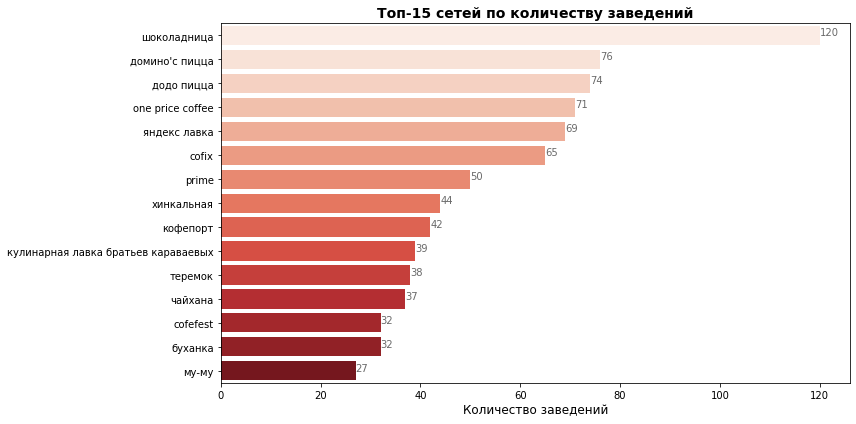

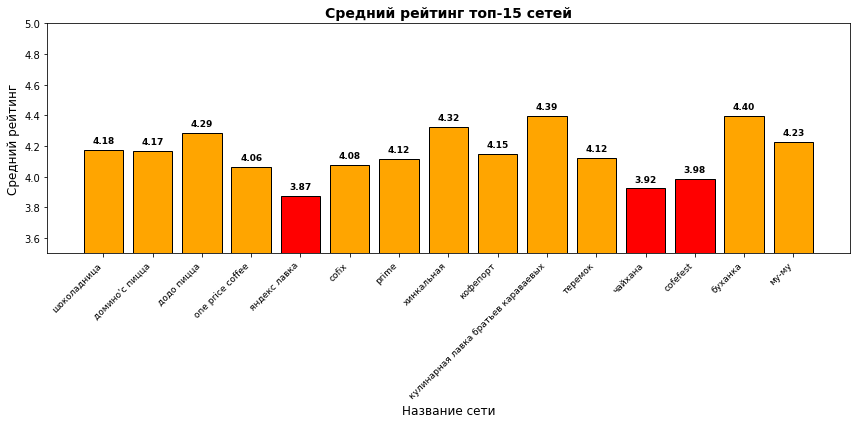

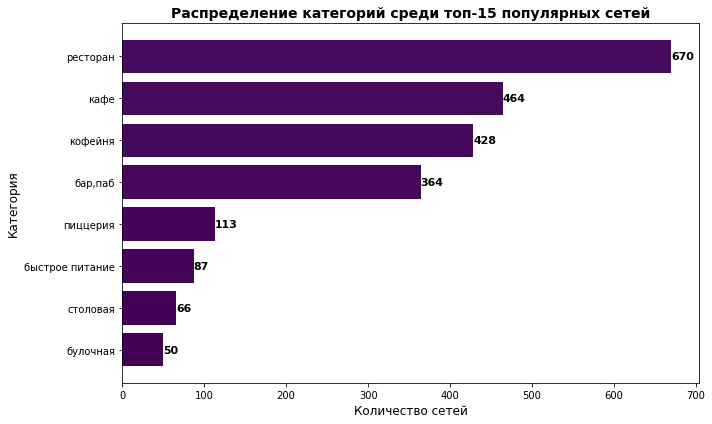

In [33]:
# Группировка по названиям сетевых заведений
top_chains = df[df['chain']].groupby('name_normalized').agg({
    'id': 'count',           
    'rating': 'mean',       
    'category': 'first'     
}).reset_index()

top_chains = top_chains[top_chains['id'] >= 5].sort_values('id', ascending=False).head(15)

top_chains.columns = ['Название сети', 'Кол-во заведений', 'Средний рейтинг', 'Категория']

print("ТОП-15 ПОПУЛЯРНЫХ СЕТЕЙ В МОСКВЕ")
print(top_chains.to_string(index=False))


#  Количество заведений
plt.figure(figsize=(12, 6))

ax = sns.barplot(x=top_chains['Кол-во заведений'],
                 y=top_chains['Название сети'],
                 palette="Reds")

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", 
                (p.get_width(), p.get_y() + p.get_height()/2),  
                fontsize=10,
                color='dimgrey')

plt.title('Топ-15 сетей по количеству заведений', fontsize=14, fontweight='bold')
plt.xlabel('Количество заведений', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# Средний рейтинг 
plt.figure(figsize=(12, 6))
colors = ['red' if x < 4 else 'orange' if x < 4.5 else 'green' for x in top_chains['Средний рейтинг']]
bars2 = plt.bar(top_chains['Название сети'], top_chains['Средний рейтинг'], color=colors, edgecolor='black')
plt.xlabel('Название сети', fontsize=12)
plt.ylabel('Средний рейтинг', fontsize=12)
plt.title('Средний рейтинг топ-15 сетей', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylim(3.5, 5.0)


for bar, rating in zip(bars2, top_chains['Средний рейтинг']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'{rating:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#  топ-15 сетей
plt.figure(figsize=(10, 6))
category_counts_sorted = category_counts.sort_values(ascending=True)
bars3 = plt.barh(category_counts_sorted.index, category_counts_sorted.values, 
                 color=plt.cm.viridis(range(len(category_counts_sorted))))
plt.xlabel('Количество сетей', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.title('Распределение категорий среди топ-15 популярных сетей', fontsize=14, fontweight='bold')

for bar, count in zip(bars3, category_counts_sorted.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{int(count)}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


Вывод:

1. Самая популярная сеть: 'шоколадница' - 120 заведений
   Её средний рейтинг: 4.18
   Категория: кофейня

2. Сеть с самым высоким рейтингом: 'буханка' - 4.40
   Количество заведений: 32
   Категория: булочная

3. Сеть с самым низким рейтингом: 'яндекс лавка' - 3.87
   Категория: ресторан

4. Доминирующая категория: кофейня (5 сетей, 33%)

5. Корреляция между популярностью сети и её рейтингом: -0.117
    Слабая связь
   

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? 


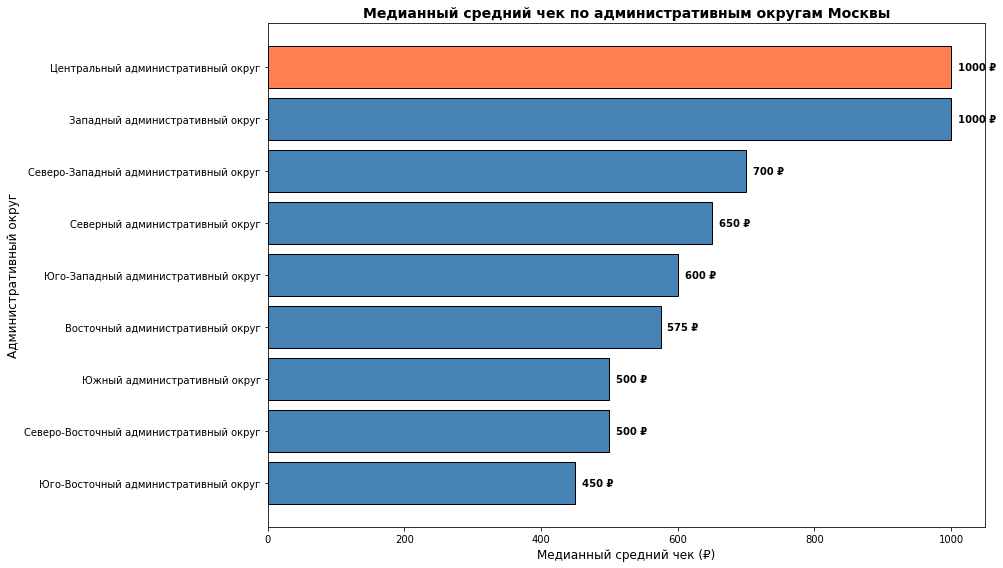

In [34]:

district_stats = df.groupby('district')['middle_avg_bill'].agg(['median', 'mean', 'count', 'std']).round(2).reset_index()
district_stats.columns = ['Округ', 'Медиана (₽)', 'Среднее (₽)', 'Кол-во заведений', 'Станд. отклонение']
district_stats = district_stats.sort_values('Медиана (₽)', ascending=False)

cao_median = district_stats[district_stats['Округ'] == 'Центральный административный округ']['Медиана (₽)'].values[0]
cao_mean = district_stats[district_stats['Округ'] == 'Центральный административный округ']['Среднее (₽)'].values[0]

district_stats['Отклонение от ЦАО (медиана)'] = district_stats['Медиана (₽)'] - cao_median
district_stats['Отклонение % от ЦАО'] = ((district_stats['Медиана (₽)'] / cao_median - 1) * 100).round(1)


plt.figure(figsize=(14, 8))
district_stats_sorted = district_stats.sort_values('Медиана (₽)', ascending=True)
colors = ['coral' if x == 'Центральный административный округ' else 'steelblue' for x in district_stats_sorted['Округ']]

bars = plt.barh(district_stats_sorted['Округ'], district_stats_sorted['Медиана (₽)'], color=colors, edgecolor='black')

for bar, median_val in zip(bars, district_stats_sorted['Медиана (₽)']):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'{median_val:.0f} ₽', va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlabel('Медианный средний чек (₽)', fontsize=12)
plt.ylabel('Административный округ', fontsize=12)
plt.title('Медианный средний чек по административным округам Москвы', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


1. Максимальный медианный чек: 1000 ₽ (Западный административный округ)
2. Минимальный медианный чек: 450 ₽ (Юго-Восточный административный округ)
3. Разница между самым дорогим и дешевым округом: 550 ₽ (55 %)

    РЕЙТИНГ ОКРУГОВ ПО МЕДИАННОМУ СРЕДНЕМУ ЧЕКУ:
Западный     →  1000 ₽ 
Центральный  →  1000 ₽ 
Северо-Западный →   700 ₽  
Северный     →   650 ₽  
Юго-Западный →   600 ₽  
Восточный    →   575 ₽  
Северо-Восточный →   500 ₽ 
Южный        →   500 ₽ 
Юго-Восточный →   450 ₽ 

Видно зависимость снижения среднего чека по мере удаления от центра.


---

### Промежуточный вывод


1. Категории заведений:

Кафе, рестораны и кофейни составляют 70% рынка, что указывает на высокую конкуренцию, но и стабильный спрос.
Столовые и бары занимают нишевые позиции (4.9% и 5.5% соответственно), что может быть как риском, так и возможностью для дифференциации.

2. Распределение по районам:

Центральный АО доминирует (26.7% заведений), здесь преобладают рестораны и кофейни. Это зона высокой конкуренции, но и повышенного спроса.
В других округах (например, Северный, Южный) распределение более равномерное, что может быть перспективным для новых проектов.

3. Сетевые vs несетевые:

38.1% заведений — сетевые. Лидеры: булочные (61.3%), пиццерии (52.1%), кофейни (51%).
Несетевые заведения чаще встречаются среди ресторанов и баров, где уникальность критична.

4. Посадочные места:

Рестораны и бары имеют наибольшее количество мест (медиана 86 и 82), что соответствует их формату.
Кофейны и столовые демонстрируют меньший разброс (IQR 12 и 8), указывая на стандартизацию.
Аномалия: кафе имеют фиксированную медиану 60 мест (IQR=0).

5. Рейтинги:

Самые высокие оценки у баров (4.39), пиццерий (4.30), ресторанов (4.29).
Низкие рейтинги у столовых (4.21) и фастфуда (4.05), что может быть связано с качеством обслуживания.

6. Корреляции:

Ценовая категория и рейтинг положительно связаны: заведения с ценами «выше среднего» имеют более высокие оценки (4.43).
Центральный округ коррелирует с высокими рейтингами (4.38), что объясняется концентрацией премиальных заведений.

7. Топ сетей:

Лидеры: Шоколадница (120 заведений), Додо Пицца (74), Домино’с (76).
Средние рейтинги сетей (4.0–4.3) указывают на стабильность, но отсутствие уникальности.

8. Средний чек:

В Центральном и западном ад. округе медианный чек 1000 руб.- самый высокий среди других АО.

## 4. Итоговый вывод и рекомендации


На основе анализа данных о заведениях Москвы были изучены следующие аспекты: количество мест по категориям, рейтинги, ценовые категории, влияние круглосуточного режима, популярность сетей и их связь с рейтингом, а также географические особенности.

РЕЙТИНГИ ПО КАТЕГОРИЯМ (топ-5):
Место	Категория	Средний рейтинг
1	Бары/пабы	4.39 
2	Пиццерии	4.30 
3	Рестораны	4.29 
4	Кофейни	    4.28 
5	Булочные   ~4.20

ЦЕНОВАЯ КАТЕГОРИЯ И РЕЙТИНГ:
Умеренная положительная корреляция – более дорогие заведения получают более высокие оценки

Заведения категорий "выше среднего" и "высокие цены" лидируют по рейтингу

Низкая ценовая категория может приводить к снижению рейтинга

СЕТЕВЫЕ ЗАВЕДЕНИЯ: 
Самая популярная сеть- Шоколадница (120 заведений, рейтинг 4.18, кофейня)
Самый высокий рейтинг- Буханка (4.40, 32 заведения, булочная)
Самый низкий рейтинг - Яндекс Лавка (3.87, ресторан)
Доминирующая категория - Кофейни (33% топ-15 сетей)

Популярность сети не гарантирует высокий рейтинг. Маленькие сети (как "Буханка") могут иметь отличные оценки.

КРУГЛОСУТОЧНЫЙ РЕЖИМ- Не оказывает значимого влияния на рейтинг
Дополнительные затраты на круглосуточную работу экономически неоправданны

ГЕОГРАФИЯ: Центральном и западном административных округах средний чек вышеЮ остальных районов.
Высокая проходимость компенсирует более высокую арендную ставку

Для перспективного заведения нужно найти баланс между между локацией, ценовой политикой и уникальностью концепции.


ОБЩИЕ РЕКОМЕНДИЦИИ:
Выбирайте правильную категорию:

Бар/паб, пиццерия, ресторан, кофейня – стабильно высокие рейтинги

Избегайте: столовые, обычные кафе, быстрое питание (низкие оценки)

Ценовая политика:

Ориентируйтесь на категории "выше среднего" или "высокие цены"

Местоположение:

ЦАО – приоритет (высокая проходимость, платежеспособная аудитория)

Видно зависимость повышения среднего чека по мере приближения к центру.

Размер заведения:

Ориентируйтесь на медианные значения по вашей категории

Для пиццерий допустим широкий диапазон (от 55 до 95 мест)


СТРАТЕГИЧЕСКИЙ ПОРТРЕТ ИДЕАЛЬНОГО ЗАВЕДЕНИЯ:
Бар, пиццерия или ресторан
Ценовая категория-Выше среднего / высокие цены
Центральный или западный административный округ
Количество мест	80-90 (в зависимости от формата)
Не обязательно что-то сетевое 